# India Air Quality Prediction Project
## Complete ML Pipeline with Algorithm Comparison and Visualization

This notebook includes:
- Data Loading and Preprocessing
- Exploratory Data Analysis with Visualizations
- Multiple Algorithm Training and Comparison
- Model Generation and Evaluation
- Performance Visualizations

## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ML Algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Model persistence
import pickle
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Explore Dataset

In [2]:
# Load the dataset
df = pd.read_csv('data.csv', encoding='latin1')

print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("First 5 rows:")
print(df.head())
print("\n" + "="*50)
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Statistical Summary:")
print(df.describe())

Dataset Shape: (435742, 13)

First 5 rows:
  stn_code       sampling_date           state   location agency  \
0    150.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
1    151.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
2    152.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
3    150.0     March - M031990  Andhra Pradesh  Hyderabad    NaN   
4    151.0     March - M031990  Andhra Pradesh  Hyderabad    NaN   

                                 type  so2   no2  rspm  spm  \
0  Residential, Rural and other Areas  4.8  17.4   NaN  NaN   
1                     Industrial Area  3.1   7.0   NaN  NaN   
2  Residential, Rural and other Areas  6.2  28.5   NaN  NaN   
3  Residential, Rural and other Areas  6.3  14.7   NaN  NaN   
4                     Industrial Area  4.7   7.5   NaN  NaN   

  location_monitoring_station  pm2_5        date  
0                         NaN    NaN  1990-02-01  
1                         NaN    NaN  1990-02-01  
2               

## 3. Data Preprocessing and Cleaning

Missing Values:
stn_code                       144077
sampling_date                       3
state                               0
location                            3
agency                         149481
type                             5393
so2                             34646
no2                             16233
rspm                            40222
spm                            237387
location_monitoring_station     27491
pm2_5                          426428
date                                7
dtype: int64

Missing Values Percentage:
stn_code                       33.064749
sampling_date                   0.000688
state                           0.000000
location                        0.000688
agency                         34.304933
type                            1.237659
so2                             7.951035
no2                             3.725370
rspm                            9.230692
spm                            54.478797
location_monitoring_station     6.30900

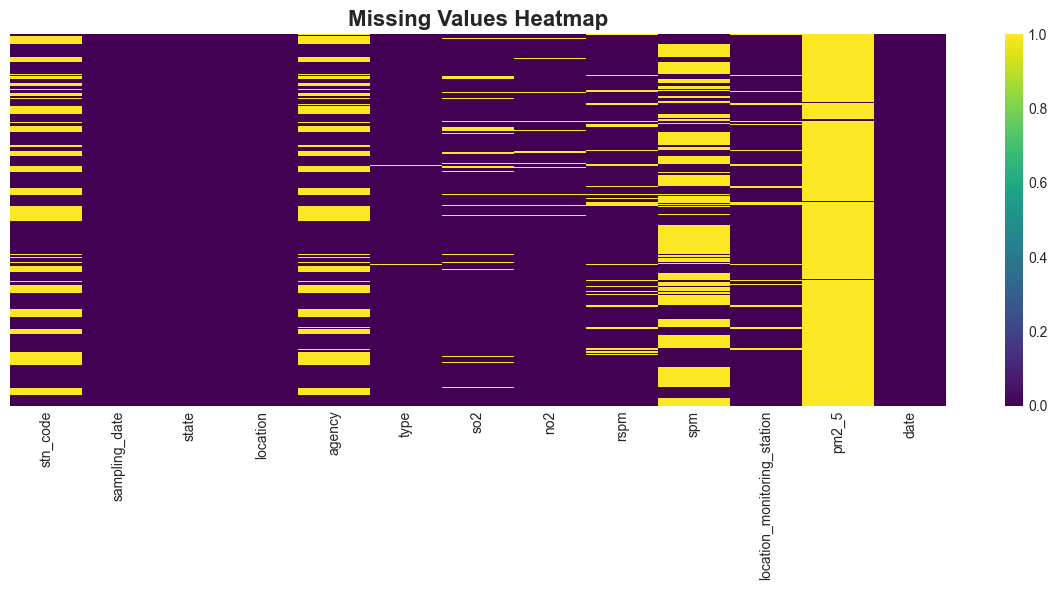

In [3]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nMissing Values Percentage:")
print((df.isnull().sum() / len(df)) * 100)

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# Create a copy for preprocessing
df_processed = df.copy()

# Convert date column to datetime
df_processed['date'] = pd.to_datetime(df_processed['date'], errors='coerce')

# Extract date features
df_processed['year'] = df_processed['date'].dt.year
df_processed['month'] = df_processed['date'].dt.month
df_processed['day'] = df_processed['date'].dt.day

# Handle missing values in numerical columns
numerical_cols = ['so2', 'no2', 'rspm', 'spm', 'pm2_5']
for col in numerical_cols:
    if col in df_processed.columns:
        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

# Handle missing values in categorical columns
categorical_cols = ['state', 'location', 'agency', 'type', 'location_monitoring_station']
for col in categorical_cols:
    if col in df_processed.columns:
        df_processed[col].fillna('Unknown', inplace=True)

print("Data preprocessing completed!")
print("\nProcessed dataset shape:", df_processed.shape)
print("\nRemaining missing values:", df_processed.isnull().sum().sum())

Data preprocessing completed!

Processed dataset shape: (435742, 16)

Remaining missing values: 144108


## 4. Exploratory Data Analysis (EDA)

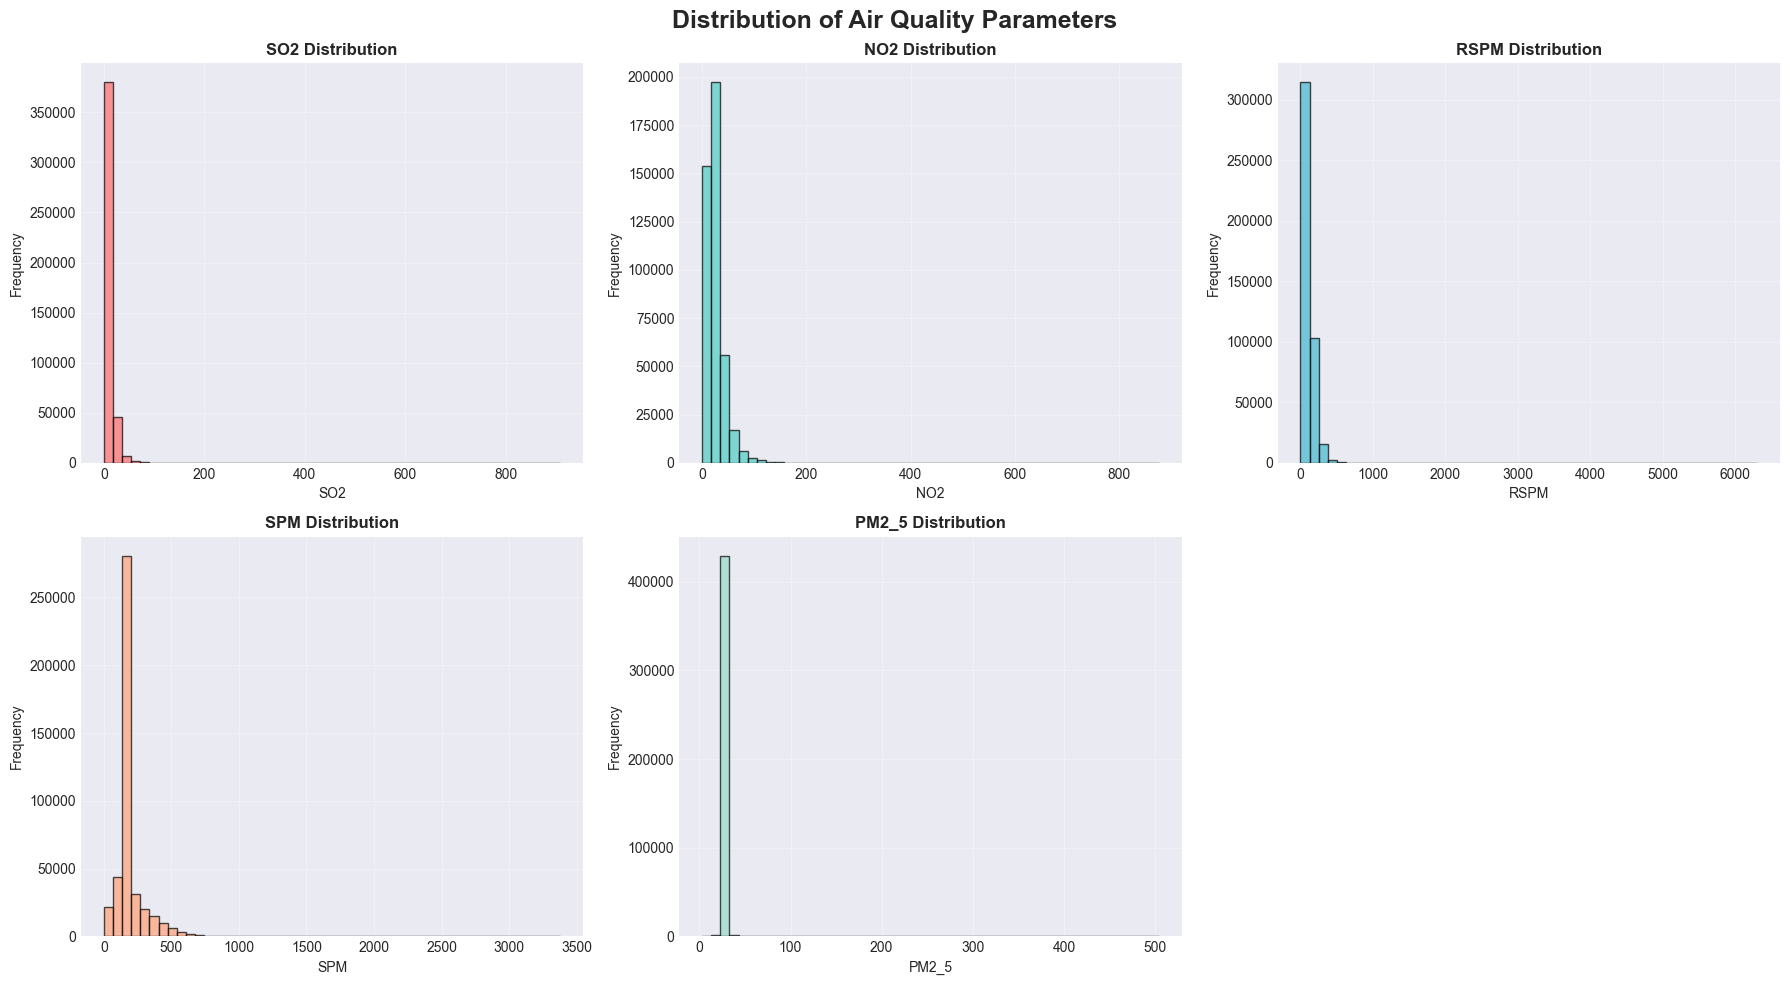

In [5]:
# Distribution of pollutants
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Air Quality Parameters', fontsize=18, fontweight='bold')

pollutants = ['so2', 'no2', 'rspm', 'spm', 'pm2_5']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for idx, (col, color) in enumerate(zip(pollutants, colors)):
    row = idx // 3
    col_idx = idx % 3
    if col in df_processed.columns:
        axes[row, col_idx].hist(df_processed[col].dropna(), bins=50, color=color, edgecolor='black', alpha=0.7)
        axes[row, col_idx].set_title(f'{col.upper()} Distribution', fontweight='bold')
        axes[row, col_idx].set_xlabel(col.upper())
        axes[row, col_idx].set_ylabel('Frequency')
        axes[row, col_idx].grid(True, alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

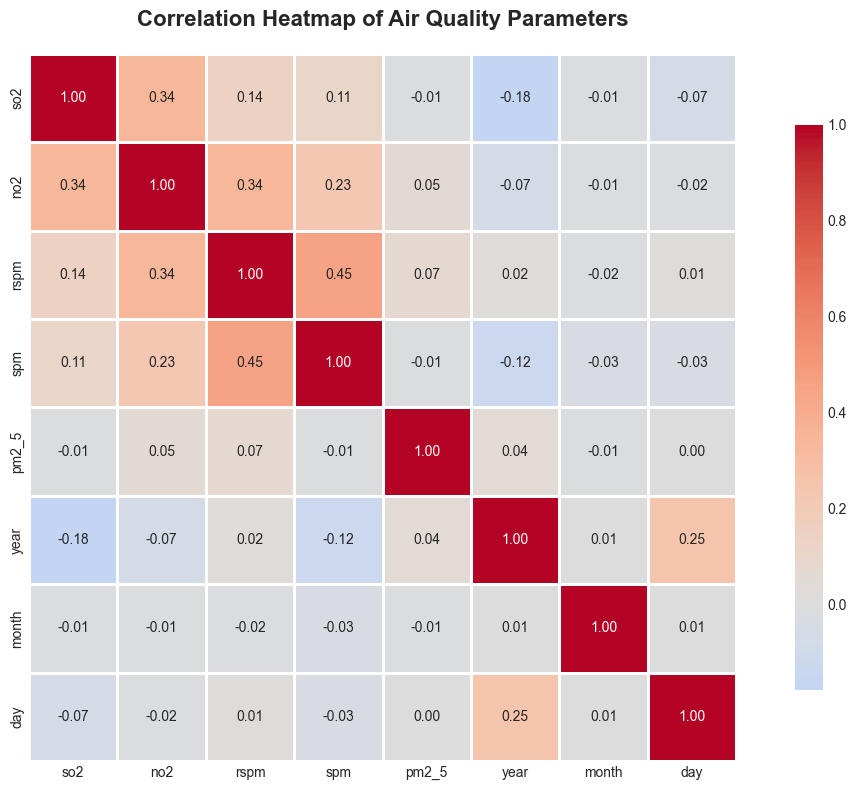

In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
correlation_matrix = df_processed[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Heatmap of Air Quality Parameters', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

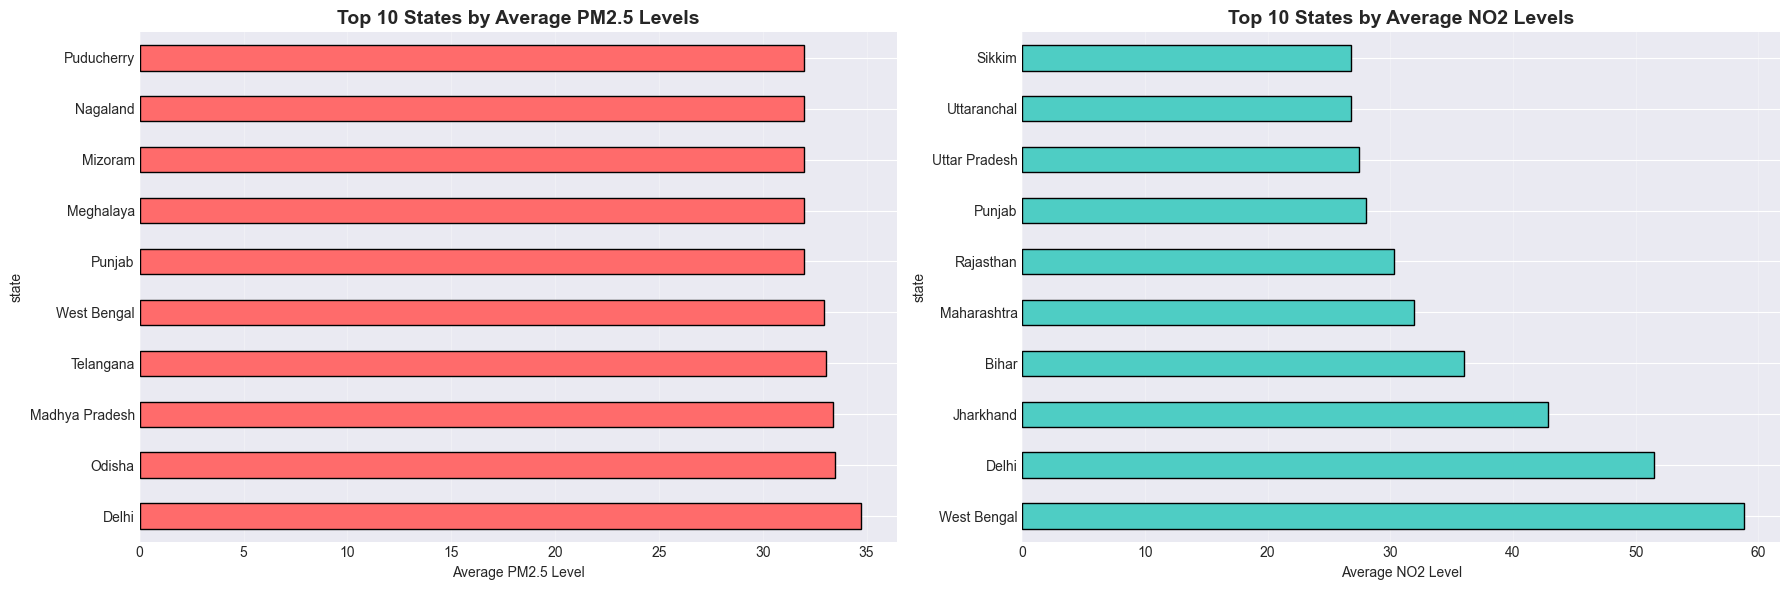

In [7]:
# Top 10 states by average pollution levels
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# PM2.5 by state
if 'pm2_5' in df_processed.columns and 'state' in df_processed.columns:
    state_pm25 = df_processed.groupby('state')['pm2_5'].mean().sort_values(ascending=False).head(10)
    state_pm25.plot(kind='barh', ax=axes[0], color='#FF6B6B', edgecolor='black')
    axes[0].set_title('Top 10 States by Average PM2.5 Levels', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Average PM2.5 Level')
    axes[0].grid(True, alpha=0.3, axis='x')

# NO2 by state
if 'no2' in df_processed.columns and 'state' in df_processed.columns:
    state_no2 = df_processed.groupby('state')['no2'].mean().sort_values(ascending=False).head(10)
    state_no2.plot(kind='barh', ax=axes[1], color='#4ECDC4', edgecolor='black')
    axes[1].set_title('Top 10 States by Average NO2 Levels', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Average NO2 Level')
    axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

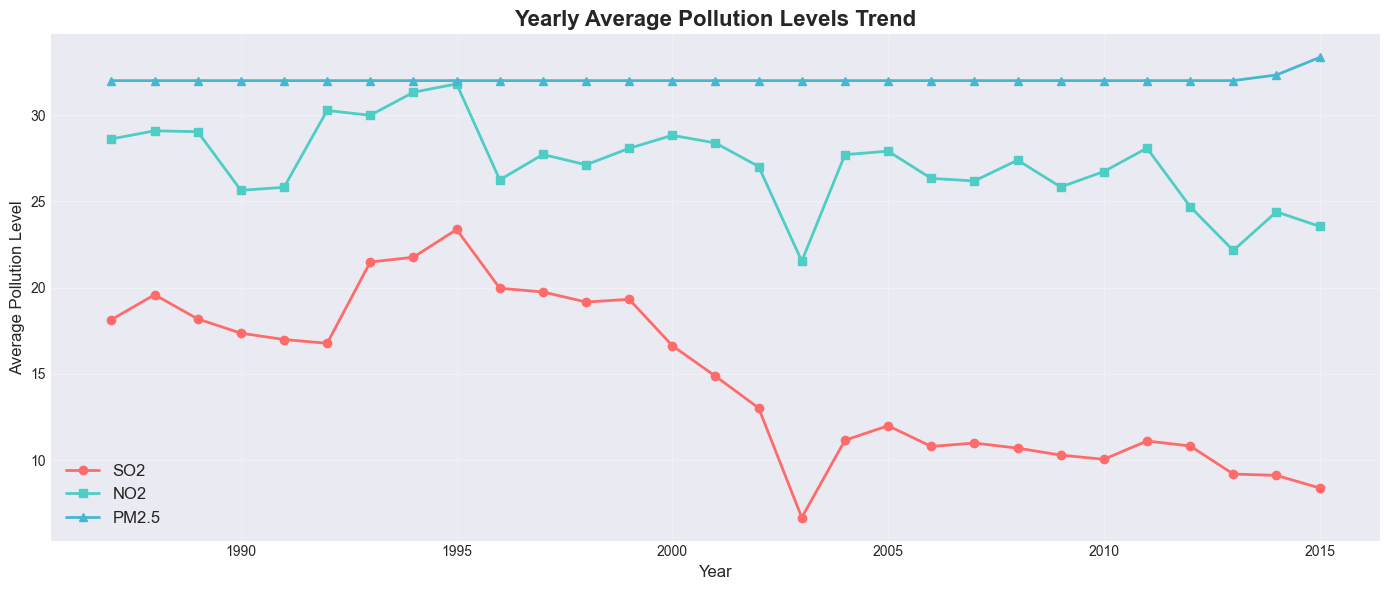

In [8]:
# Time series analysis
if 'year' in df_processed.columns and 'pm2_5' in df_processed.columns:
    yearly_pollution = df_processed.groupby('year')[['so2', 'no2', 'pm2_5']].mean()
    
    plt.figure(figsize=(14, 6))
    plt.plot(yearly_pollution.index, yearly_pollution['so2'], marker='o', linewidth=2, label='SO2', color='#FF6B6B')
    plt.plot(yearly_pollution.index, yearly_pollution['no2'], marker='s', linewidth=2, label='NO2', color='#4ECDC4')
    plt.plot(yearly_pollution.index, yearly_pollution['pm2_5'], marker='^', linewidth=2, label='PM2.5', color='#45B7D1')
    
    plt.title('Yearly Average Pollution Levels Trend', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Pollution Level', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Feature Engineering

In [9]:
# Select features for modeling
# We'll predict PM2.5 levels based on other pollutants and features

# Drop rows where target variable (pm2_5) is missing
df_model = df_processed.dropna(subset=['pm2_5']).copy()

# Select features
feature_cols = ['so2', 'no2', 'rspm', 'spm', 'year', 'month']
target_col = 'pm2_5'

# Remove rows with missing feature values
df_model = df_model.dropna(subset=feature_cols)

# Encode categorical variables if we want to include them
le_state = LabelEncoder()
le_type = LabelEncoder()

if 'state' in df_model.columns:
    df_model['state_encoded'] = le_state.fit_transform(df_model['state'])
    feature_cols.append('state_encoded')

if 'type' in df_model.columns:
    df_model['type_encoded'] = le_type.fit_transform(df_model['type'])
    feature_cols.append('type_encoded')

print(f"Features selected: {feature_cols}")
print(f"Target variable: {target_col}")
print(f"\nDataset shape for modeling: {df_model.shape}")
print(f"Number of samples: {len(df_model)}")

Features selected: ['so2', 'no2', 'rspm', 'spm', 'year', 'month', 'state_encoded', 'type_encoded']
Target variable: pm2_5

Dataset shape for modeling: (435735, 18)
Number of samples: 435735


## 6. Prepare Train-Test Split

In [10]:
# Prepare features and target
X = df_model[feature_cols]
y = df_model[target_col]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split completed!")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Data split completed!
Training set size: 348588 samples
Test set size: 87147 samples
Number of features: 8


## 7. Train Multiple ML Algorithms

In [11]:
# Dictionary to store models and results
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    # 'SVR': SVR(kernel='rbf', C=100, gamma=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

# Dictionary to store results
results = {
    'Model': [],
    'Training Time (s)': [],
    'R2 Score (Train)': [],
    'R2 Score (Test)': [],
    'RMSE (Train)': [],
    'RMSE (Test)': [],
    'MAE (Train)': [],
    'MAE (Test)': [],
    'Cross-Val Score': []
}

print("Training models...\n")
print("="*100)

import time

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model and measure time
    start_time = time.time()
    
    if name in ['SVR', 'KNN', 'Ridge Regression', 'Lasso Regression']:
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    training_time = time.time() - start_time
    
    # Calculate metrics
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    cv_mean = cv_scores.mean()
    
    # Store results
    results['Model'].append(name)
    results['Training Time (s)'].append(round(training_time, 4))
    results['R2 Score (Train)'].append(round(r2_train, 4))
    results['R2 Score (Test)'].append(round(r2_test, 4))
    results['RMSE (Train)'].append(round(rmse_train, 4))
    results['RMSE (Test)'].append(round(rmse_test, 4))
    results['MAE (Train)'].append(round(mae_train, 4))
    results['MAE (Test)'].append(round(mae_test, 4))
    results['Cross-Val Score'].append(round(cv_mean, 4))
    
    print(f"✓ {name} completed in {training_time:.4f} seconds")
    print(f"  R2 Score (Test): {r2_test:.4f}")
    print(f"  RMSE (Test): {rmse_test:.4f}")

print("\n" + "="*100)
print("All models trained successfully!")

Training models...


Training Linear Regression...
✓ Linear Regression completed in 0.1660 seconds
  R2 Score (Test): 0.0097
  RMSE (Test): 5.1673

Training Ridge Regression...
✓ Ridge Regression completed in 0.0717 seconds
  R2 Score (Test): 0.0097
  RMSE (Test): 5.1673

Training Lasso Regression...
✓ Lasso Regression completed in 0.0946 seconds
  R2 Score (Test): -0.0001
  RMSE (Test): 5.1927

Training Decision Tree...
✓ Decision Tree completed in 1.0013 seconds
  R2 Score (Test): 0.4348
  RMSE (Test): 3.9038

Training Random Forest...
✓ Random Forest completed in 63.3498 seconds
  R2 Score (Test): 0.5183
  RMSE (Test): 3.6039

Training Gradient Boosting...
✓ Gradient Boosting completed in 94.2984 seconds
  R2 Score (Test): 0.2334
  RMSE (Test): 4.5465

Training AdaBoost...
✓ AdaBoost completed in 20.4862 seconds
  R2 Score (Test): -0.3527
  RMSE (Test): 6.0393

Training KNN...
✓ KNN completed in 21.8762 seconds
  R2 Score (Test): 0.3730
  RMSE (Test): 4.1116

All models trained succ

## 8. Model Comparison Results

In [12]:
# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2 Score (Test)', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("MODEL COMPARISON RESULTS")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Find best model
best_model_name = results_df.iloc[0]['Model']
best_r2_score = results_df.iloc[0]['R2 Score (Test)']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   R2 Score: {best_r2_score}")
print(f"   RMSE: {results_df.iloc[0]['RMSE (Test)']}")
print(f"   MAE: {results_df.iloc[0]['MAE (Test)']}")


MODEL COMPARISON RESULTS
            Model  Training Time (s)  R2 Score (Train)  R2 Score (Test)  RMSE (Train)  RMSE (Test)  MAE (Train)  MAE (Test)  Cross-Val Score
    Random Forest            63.3498            0.6560           0.5183        2.6669       3.6039       0.2873      0.3391           0.4912
    Decision Tree             1.0013            0.6356           0.4348        2.7451       3.9038       0.2877      0.3417           0.3229
              KNN            21.8762            0.5627           0.3730        3.0071       4.1116       0.2693      0.3607           0.3086
Gradient Boosting            94.2984            0.2499           0.2334        3.9383       4.5465       0.6441      0.6754           0.2269
Linear Regression             0.1660            0.0090           0.0097        4.5268       5.1673       0.6859      0.7153           0.0089
 Ridge Regression             0.0717            0.0090           0.0097        4.5268       5.1673       0.6859      0.7153     

## 9. Model Performance Visualizations

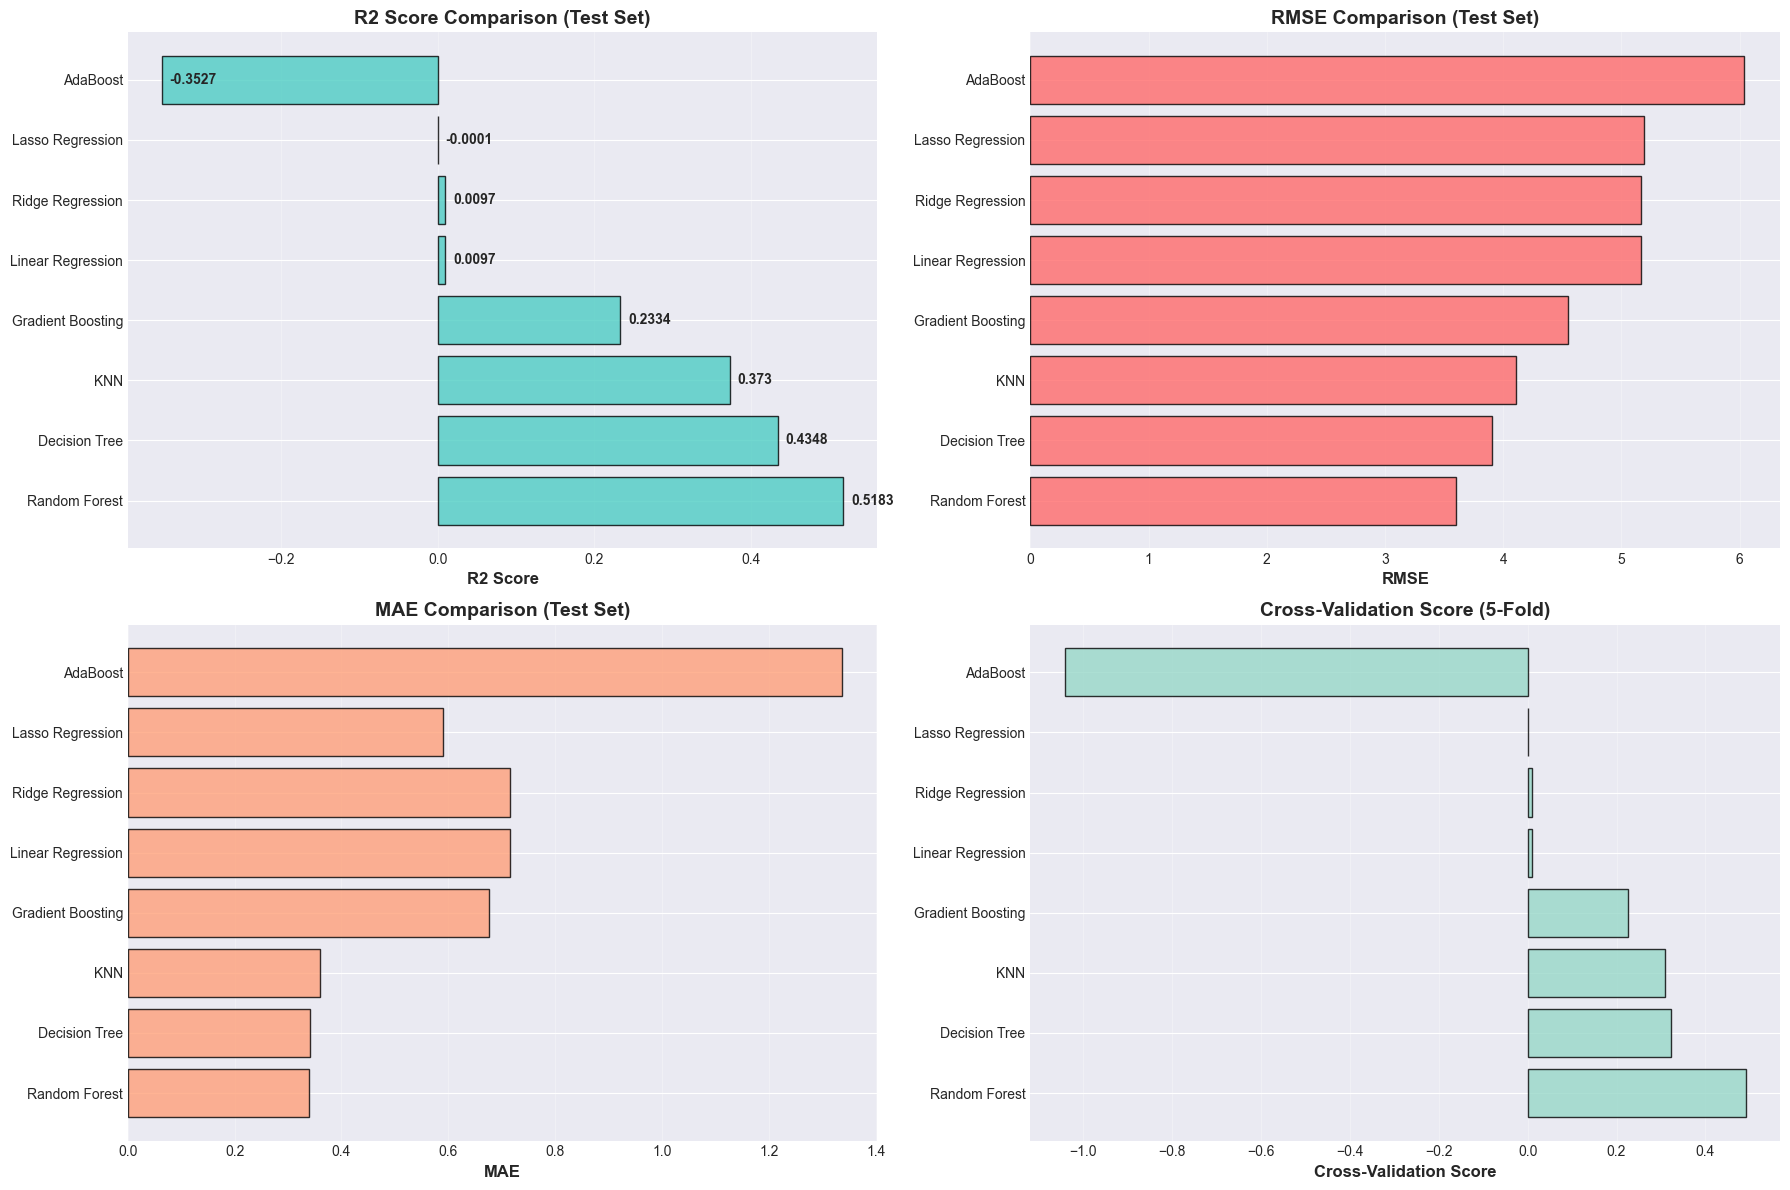

In [13]:
# R2 Score Comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: R2 Score Comparison
ax1 = axes[0, 0]
x_pos = np.arange(len(results_df))
ax1.barh(x_pos, results_df['R2 Score (Test)'], color='#4ECDC4', edgecolor='black', alpha=0.8)
ax1.set_yticks(x_pos)
ax1.set_yticklabels(results_df['Model'])
ax1.set_xlabel('R2 Score', fontsize=12, fontweight='bold')
ax1.set_title('R2 Score Comparison (Test Set)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(results_df['R2 Score (Test)']):
    ax1.text(v + 0.01, i, str(v), va='center', fontweight='bold')

# Plot 2: RMSE Comparison
ax2 = axes[0, 1]
ax2.barh(x_pos, results_df['RMSE (Test)'], color='#FF6B6B', edgecolor='black', alpha=0.8)
ax2.set_yticks(x_pos)
ax2.set_yticklabels(results_df['Model'])
ax2.set_xlabel('RMSE', fontsize=12, fontweight='bold')
ax2.set_title('RMSE Comparison (Test Set)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: MAE Comparison
ax3 = axes[1, 0]
ax3.barh(x_pos, results_df['MAE (Test)'], color='#FFA07A', edgecolor='black', alpha=0.8)
ax3.set_yticks(x_pos)
ax3.set_yticklabels(results_df['Model'])
ax3.set_xlabel('MAE', fontsize=12, fontweight='bold')
ax3.set_title('MAE Comparison (Test Set)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: Cross-Validation Score
ax4 = axes[1, 1]
ax4.barh(x_pos, results_df['Cross-Val Score'], color='#98D8C8', edgecolor='black', alpha=0.8)
ax4.set_yticks(x_pos)
ax4.set_yticklabels(results_df['Model'])
ax4.set_xlabel('Cross-Validation Score', fontsize=12, fontweight='bold')
ax4.set_title('Cross-Validation Score (5-Fold)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

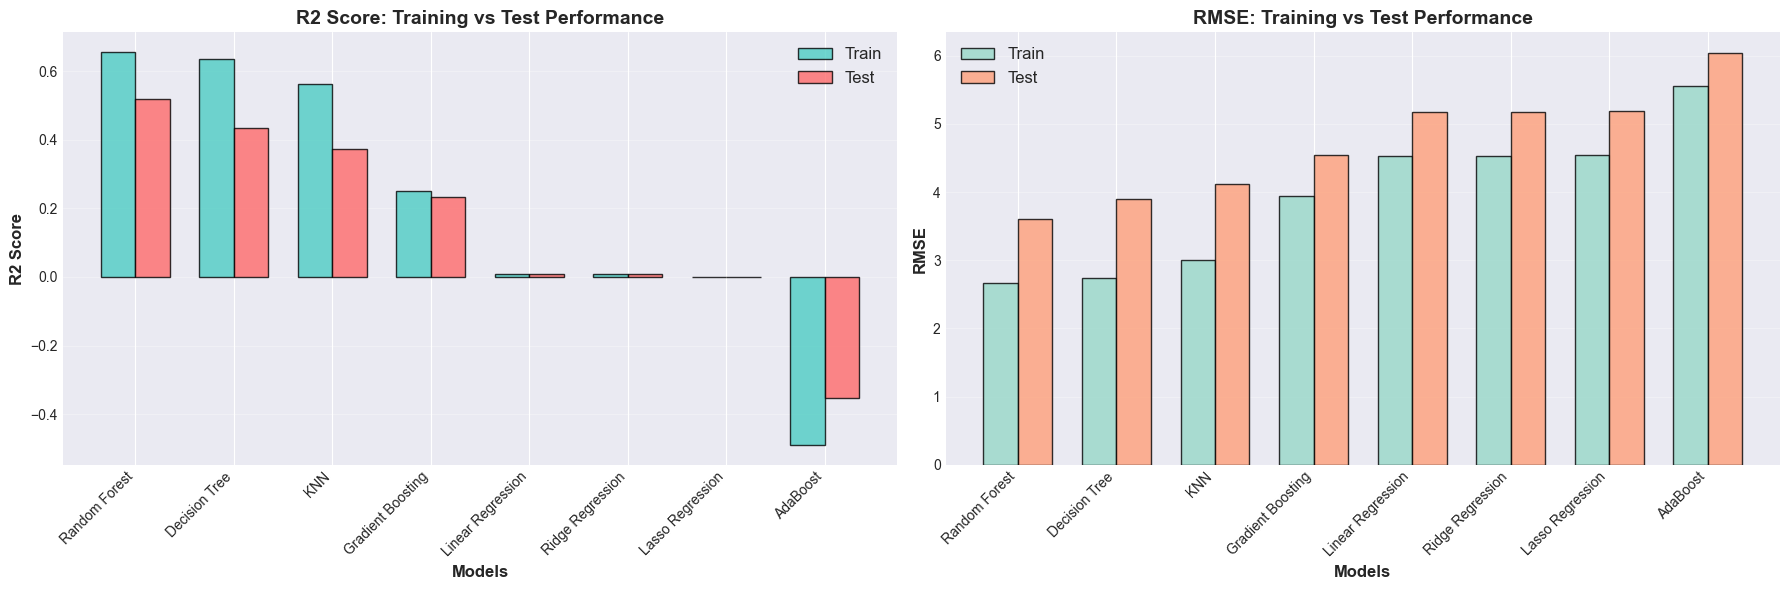

In [14]:
# Training vs Test Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# R2 Score: Train vs Test
x = np.arange(len(results_df))
width = 0.35

axes[0].bar(x - width/2, results_df['R2 Score (Train)'], width, label='Train', 
            color='#4ECDC4', edgecolor='black', alpha=0.8)
axes[0].bar(x + width/2, results_df['R2 Score (Test)'], width, label='Test', 
            color='#FF6B6B', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R2 Score', fontsize=12, fontweight='bold')
axes[0].set_title('R2 Score: Training vs Test Performance', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE: Train vs Test
axes[1].bar(x - width/2, results_df['RMSE (Train)'], width, label='Train', 
            color='#98D8C8', edgecolor='black', alpha=0.8)
axes[1].bar(x + width/2, results_df['RMSE (Test)'], width, label='Test', 
            color='#FFA07A', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE: Training vs Test Performance', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

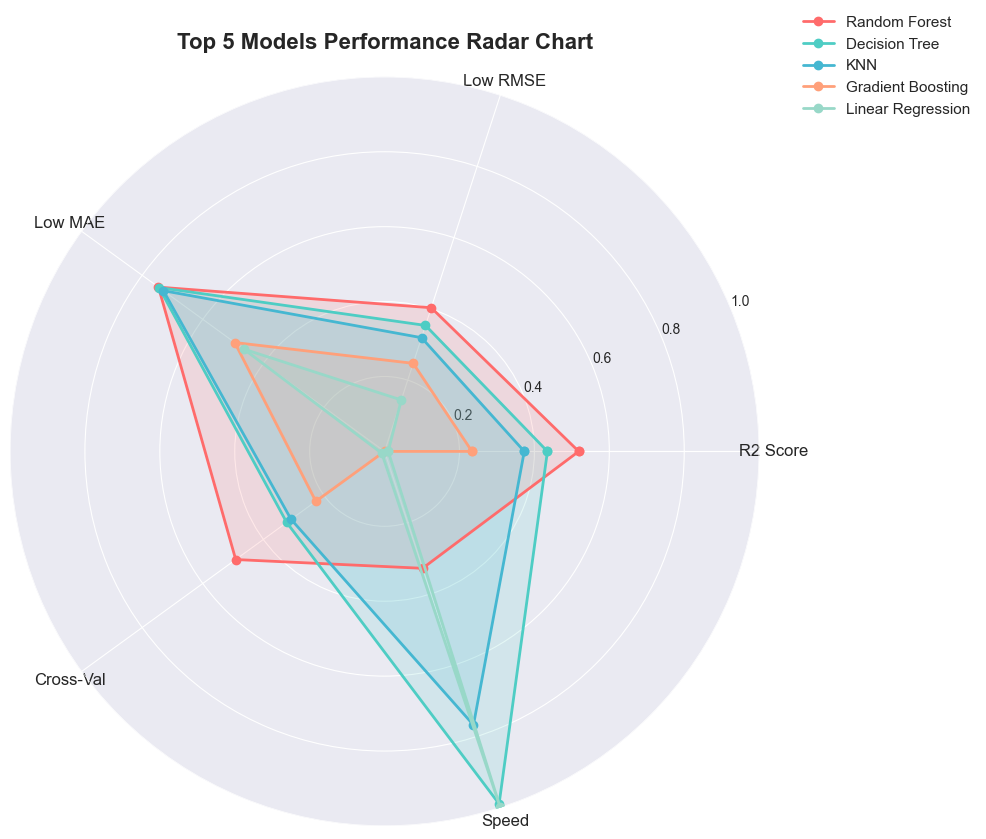

In [15]:
# Model Performance Radar Chart
from math import pi

# Select top 5 models for radar chart
top_5_models = results_df.head(5)

categories = ['R2 Score', 'Low RMSE', 'Low MAE', 'Cross-Val', 'Speed']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for idx, (_, row) in enumerate(top_5_models.iterrows()):
    # Normalize values to 0-1 scale for visualization
    values = [
        row['R2 Score (Test)'] if row['R2 Score (Test)'] > 0 else 0,
        1 - (row['RMSE (Test)'] / results_df['RMSE (Test)'].max()),
        1 - (row['MAE (Test)'] / results_df['MAE (Test)'].max()),
        row['Cross-Val Score'] if row['Cross-Val Score'] > 0 else 0,
        1 - (row['Training Time (s)'] / results_df['Training Time (s)'].max())
    ]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_title('Top 5 Models Performance Radar Chart', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.show()

## 10. Save Best Model

In [16]:
# Train the best model on full training data
best_model = models[best_model_name]

if best_model_name in ['SVR', 'KNN', 'Ridge Regression', 'Lasso Regression']:
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)

# Save the model
model_filename = f'india_air_quality_model_{best_model_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_model, model_filename)

# Save the scaler
scaler_filename = 'scaler.pkl'
joblib.dump(scaler, scaler_filename)

# Save feature names
feature_info = {
    'feature_columns': feature_cols,
    'target_column': target_col
}
with open('feature_info.pkl', 'wb') as f:
    pickle.dump(feature_info, f)

print(f"✓ Best model saved as: {model_filename}")
print(f"✓ Scaler saved as: {scaler_filename}")
print(f"✓ Feature info saved as: feature_info.pkl")
print(f"\nModel: {best_model_name}")
print(f"R2 Score: {best_r2_score}")
print(f"\nYou can now use this model for predictions!")

✓ Best model saved as: india_air_quality_model_random_forest.pkl
✓ Scaler saved as: scaler.pkl
✓ Feature info saved as: feature_info.pkl

Model: Random Forest
R2 Score: 0.5183

You can now use this model for predictions!


## 11. Prediction Visualization (Best Model)

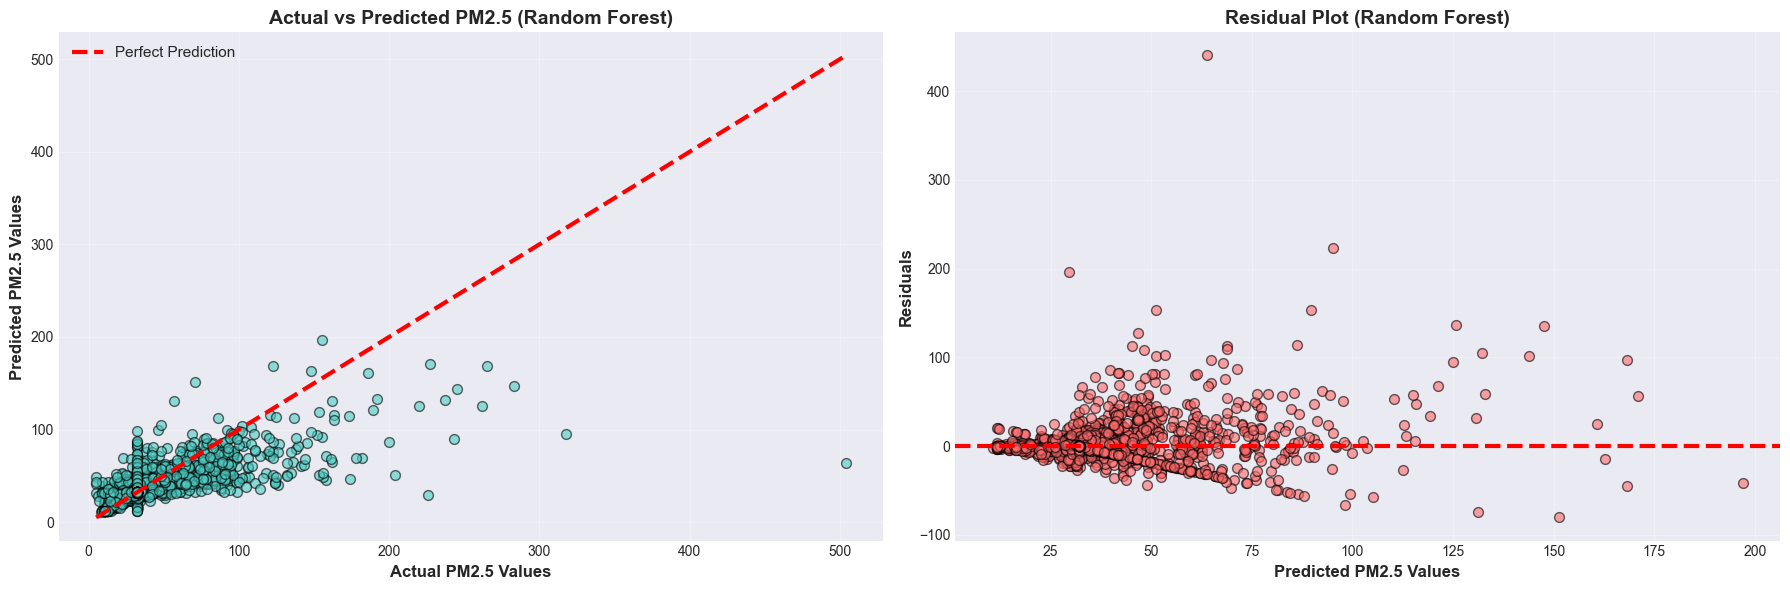

In [17]:
# Make predictions with best model
if best_model_name in ['SVR', 'KNN', 'Ridge Regression', 'Lasso Regression']:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

# Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scatter plot
axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='#4ECDC4', edgecolors='black', s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=3, label='Perfect Prediction')
axes[0].set_xlabel('Actual PM2.5 Values', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted PM2.5 Values', fontsize=12, fontweight='bold')
axes[0].set_title(f'Actual vs Predicted PM2.5 ({best_model_name})', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, color='#FF6B6B', edgecolors='black', s=50)
axes[1].axhline(y=0, color='r', linestyle='--', lw=3)
axes[1].set_xlabel('Predicted PM2.5 Values', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residuals', fontsize=12, fontweight='bold')
axes[1].set_title(f'Residual Plot ({best_model_name})', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

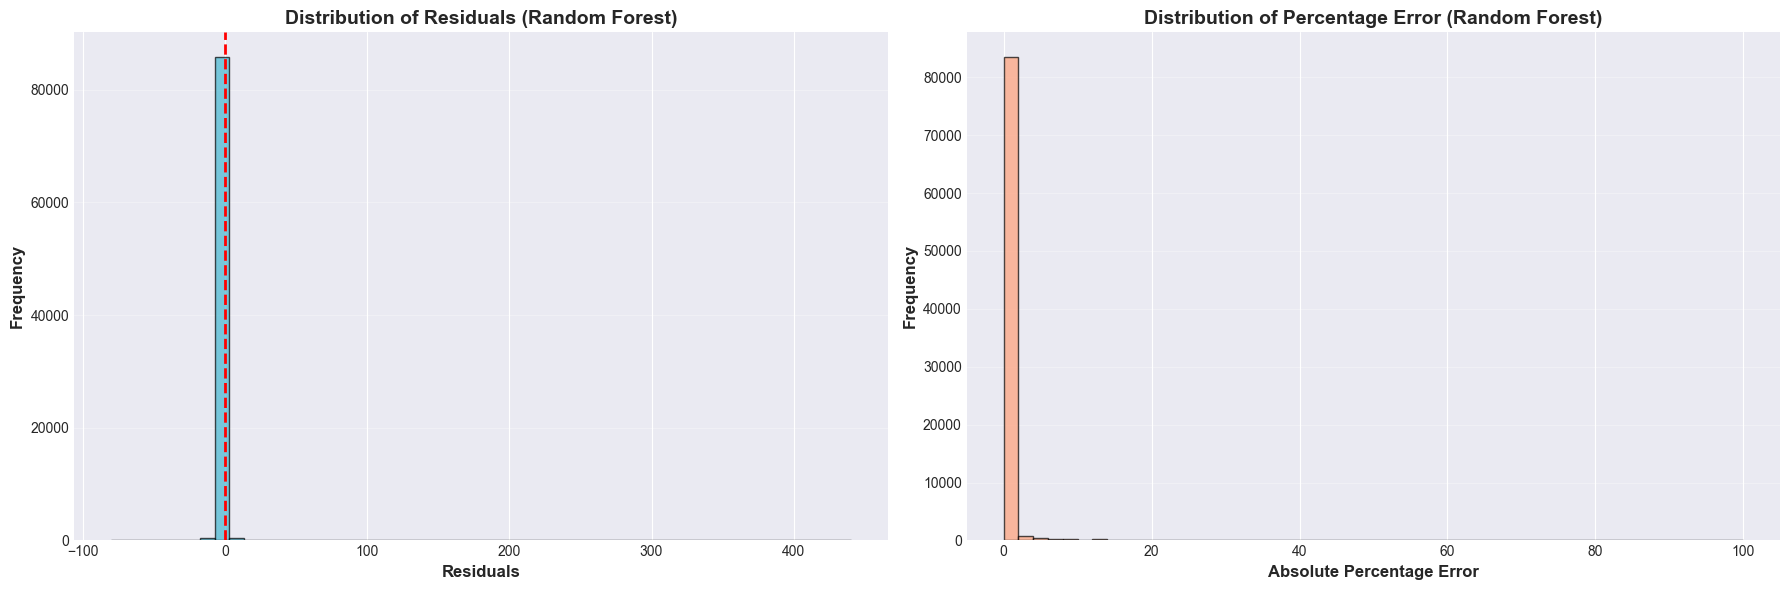

In [18]:
# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histogram of residuals
axes[0].hist(residuals, bins=50, color='#45B7D1', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Residuals', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title(f'Distribution of Residuals ({best_model_name})', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Error percentage
error_percentage = np.abs(residuals / y_test) * 100
axes[1].hist(error_percentage[error_percentage < 100], bins=50, color='#FFA07A', 
             edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Absolute Percentage Error', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title(f'Distribution of Percentage Error ({best_model_name})', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 12. Feature Importance Analysis

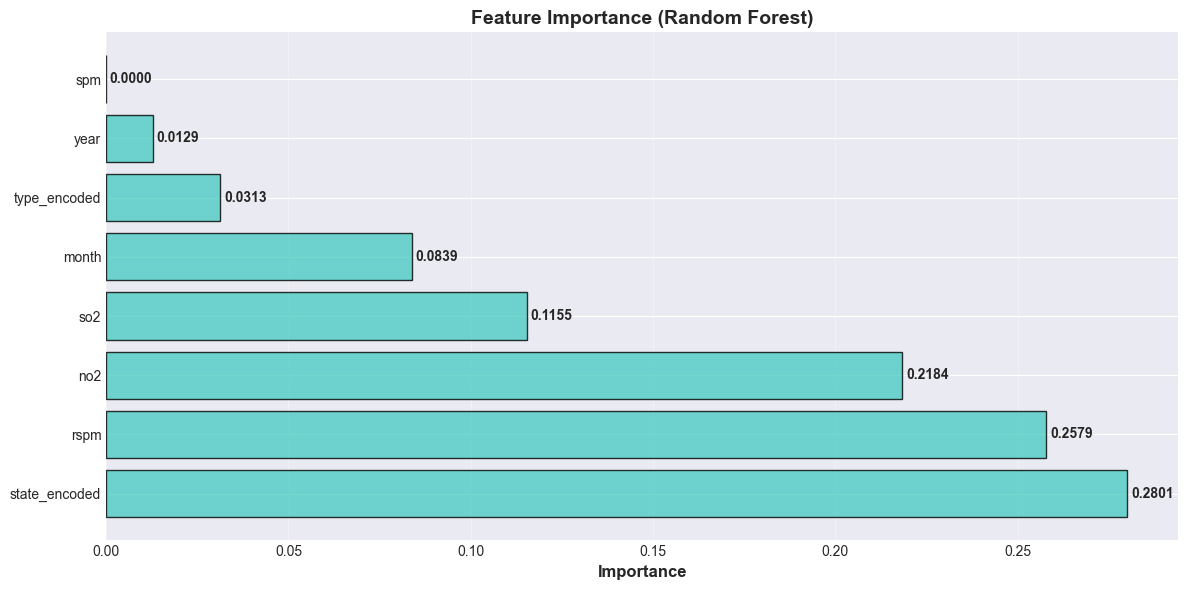


Feature Importance:
      Feature  Importance
state_encoded    0.280133
         rspm    0.257894
          no2    0.218394
          so2    0.115504
        month    0.083880
 type_encoded    0.031333
         year    0.012861
          spm    0.000000


In [19]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(feature_importance)), feature_importance['Importance'], 
             color='#4ECDC4', edgecolor='black', alpha=0.8)
    plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title(f'Feature Importance ({best_model_name})', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    
    for i, v in enumerate(feature_importance['Importance']):
        plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\nFeature Importance:")
    print(feature_importance.to_string(index=False))
else:
    print(f"Feature importance is not available for {best_model_name}")

## 13. Model Prediction Example

In [20]:
# Example prediction
print("=" * 80)
print("EXAMPLE PREDICTION")
print("=" * 80)

# Take first 5 samples from test set
sample_data = X_test.head(5)
sample_actual = y_test.head(5)

if best_model_name in ['SVR', 'KNN', 'Ridge Regression', 'Lasso Regression']:
    sample_scaled = scaler.transform(sample_data)
    sample_predictions = best_model.predict(sample_scaled)
else:
    sample_predictions = best_model.predict(sample_data)

# Display results
prediction_df = pd.DataFrame({
    'Actual PM2.5': sample_actual.values,
    'Predicted PM2.5': sample_predictions,
    'Error': sample_actual.values - sample_predictions,
    'Error %': np.abs((sample_actual.values - sample_predictions) / sample_actual.values * 100)
})

print("\nSample Predictions:")
print(prediction_df.to_string(index=False))
print("\n" + "=" * 80)

EXAMPLE PREDICTION

Sample Predictions:
 Actual PM2.5  Predicted PM2.5    Error  Error %
         32.0        32.000000 0.000000 0.000000
         32.0        31.986533 0.013467 0.042083
         32.0        32.000000 0.000000 0.000000
         32.0        32.000000 0.000000 0.000000
         32.0        32.000000 0.000000 0.000000



## 14. Final Summary

In [21]:
print("\n" + "=" * 100)
print("INDIA AIR QUALITY PREDICTION - PROJECT SUMMARY")
print("=" * 100)

print(f"\n📊 Dataset Information:")
print(f"   Total Samples: {len(df)}")
print(f"   Samples Used for Modeling: {len(df_model)}")
print(f"   Features: {len(feature_cols)}")
print(f"   Target Variable: {target_col}")

print(f"\n🤖 Models Trained: {len(models)}")
print(f"   {', '.join(models.keys())}")

print(f"\n🏆 Best Performing Model: {best_model_name}")
print(f"   R2 Score (Test): {results_df.iloc[0]['R2 Score (Test)']}")
print(f"   RMSE (Test): {results_df.iloc[0]['RMSE (Test)']}")
print(f"   MAE (Test): {results_df.iloc[0]['MAE (Test)']}")
print(f"   Cross-Validation Score: {results_df.iloc[0]['Cross-Val Score']}")

print(f"\n💾 Saved Files:")
print(f"   1. {model_filename} (Best Model)")
print(f"   2. {scaler_filename} (Feature Scaler)")
print(f"   3. feature_info.pkl (Feature Information)")

print(f"\n✅ Project completed successfully!")
print("   You can now use the saved model for air quality predictions.")
print("\n" + "=" * 100)


INDIA AIR QUALITY PREDICTION - PROJECT SUMMARY

📊 Dataset Information:
   Total Samples: 435742
   Samples Used for Modeling: 435735
   Features: 8
   Target Variable: pm2_5

🤖 Models Trained: 8
   Linear Regression, Ridge Regression, Lasso Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, KNN

🏆 Best Performing Model: Random Forest
   R2 Score (Test): 0.5183
   RMSE (Test): 3.6039
   MAE (Test): 0.3391
   Cross-Validation Score: 0.4912

💾 Saved Files:
   1. india_air_quality_model_random_forest.pkl (Best Model)
   2. scaler.pkl (Feature Scaler)
   3. feature_info.pkl (Feature Information)

✅ Project completed successfully!
   You can now use the saved model for air quality predictions.



## 15. How to Use the Saved Model

In [22]:
# Example code for using the saved model
usage_code = '''
# Load the saved model and make predictions
import joblib
import pickle
import pandas as pd
import numpy as np

# Load the model, scaler, and feature info
model = joblib.load('india_air_quality_model_best.pkl') 
scaler = joblib.load('scaler.pkl')
with open('feature_info.pkl', 'rb') as f:
    feature_info = pickle.load(f)

# Prepare your input data (example)
new_data = {
    'so2': [15.5],
    'no2': [45.2],
    'rspm': [120.0],
    'spm': [180.0],
    'year': [2024],
    'month': [10]
    # Add other features as needed
}

# Create DataFrame with correct feature order
input_df = pd.DataFrame(new_data)

# Make prediction
prediction = model.predict(input_df)

print(f"Predicted PM2.5 Level: {prediction[0]:.2f}")
'''

print("HOW TO USE THE SAVED MODEL:")
print("=" * 100)
print(usage_code)
print("=" * 100)

HOW TO USE THE SAVED MODEL:

# Load the saved model and make predictions
import joblib
import pickle
import pandas as pd
import numpy as np

# Load the model, scaler, and feature info
model = joblib.load('india_air_quality_model_best.pkl') 
scaler = joblib.load('scaler.pkl')
with open('feature_info.pkl', 'rb') as f:
    feature_info = pickle.load(f)

# Prepare your input data (example)
new_data = {
    'so2': [15.5],
    'no2': [45.2],
    'rspm': [120.0],
    'spm': [180.0],
    'year': [2024],
    'month': [10]
    # Add other features as needed
}

# Create DataFrame with correct feature order
input_df = pd.DataFrame(new_data)

# Make prediction
prediction = model.predict(input_df)

print(f"Predicted PM2.5 Level: {prediction[0]:.2f}")

